# Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:
- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.


```python
HumanMessage
    ↓
"Send an email"

AIMessage
    ↓
"I need to call send_email_tool(...)"

ToolMessage
    ↓
"Email sent successfully."

AIMessage
    ↓
"Your email has been sent."
```


```python
HumanMessage → User's request.
AIMessage → LLM's response or tool invocation.
ToolMessage → Tool's output returned to the LLM.
```

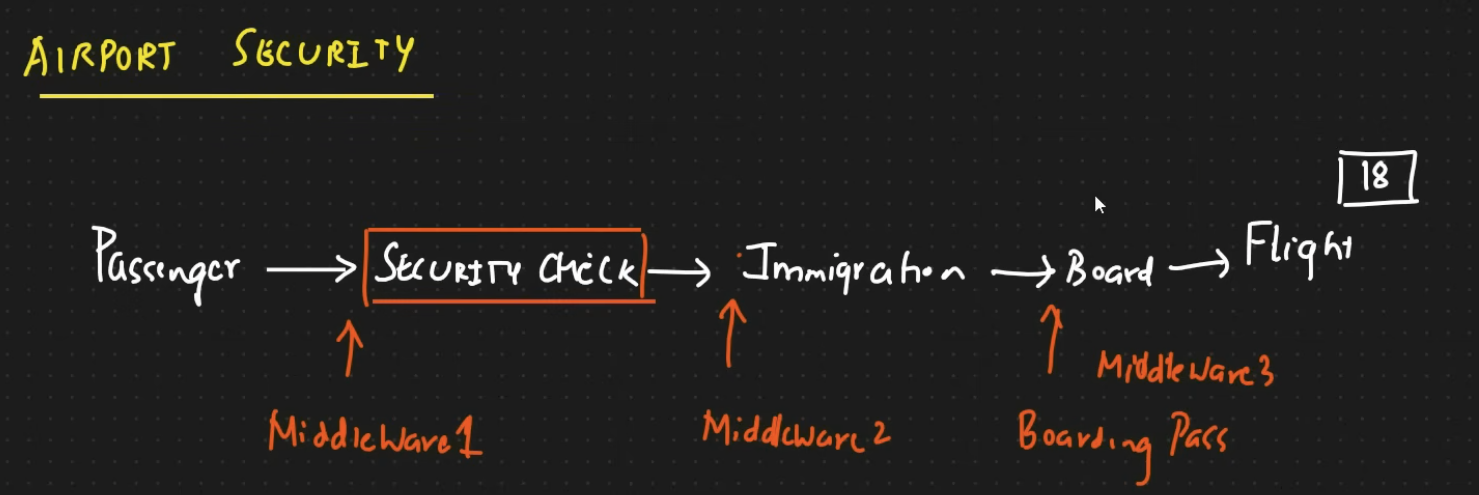

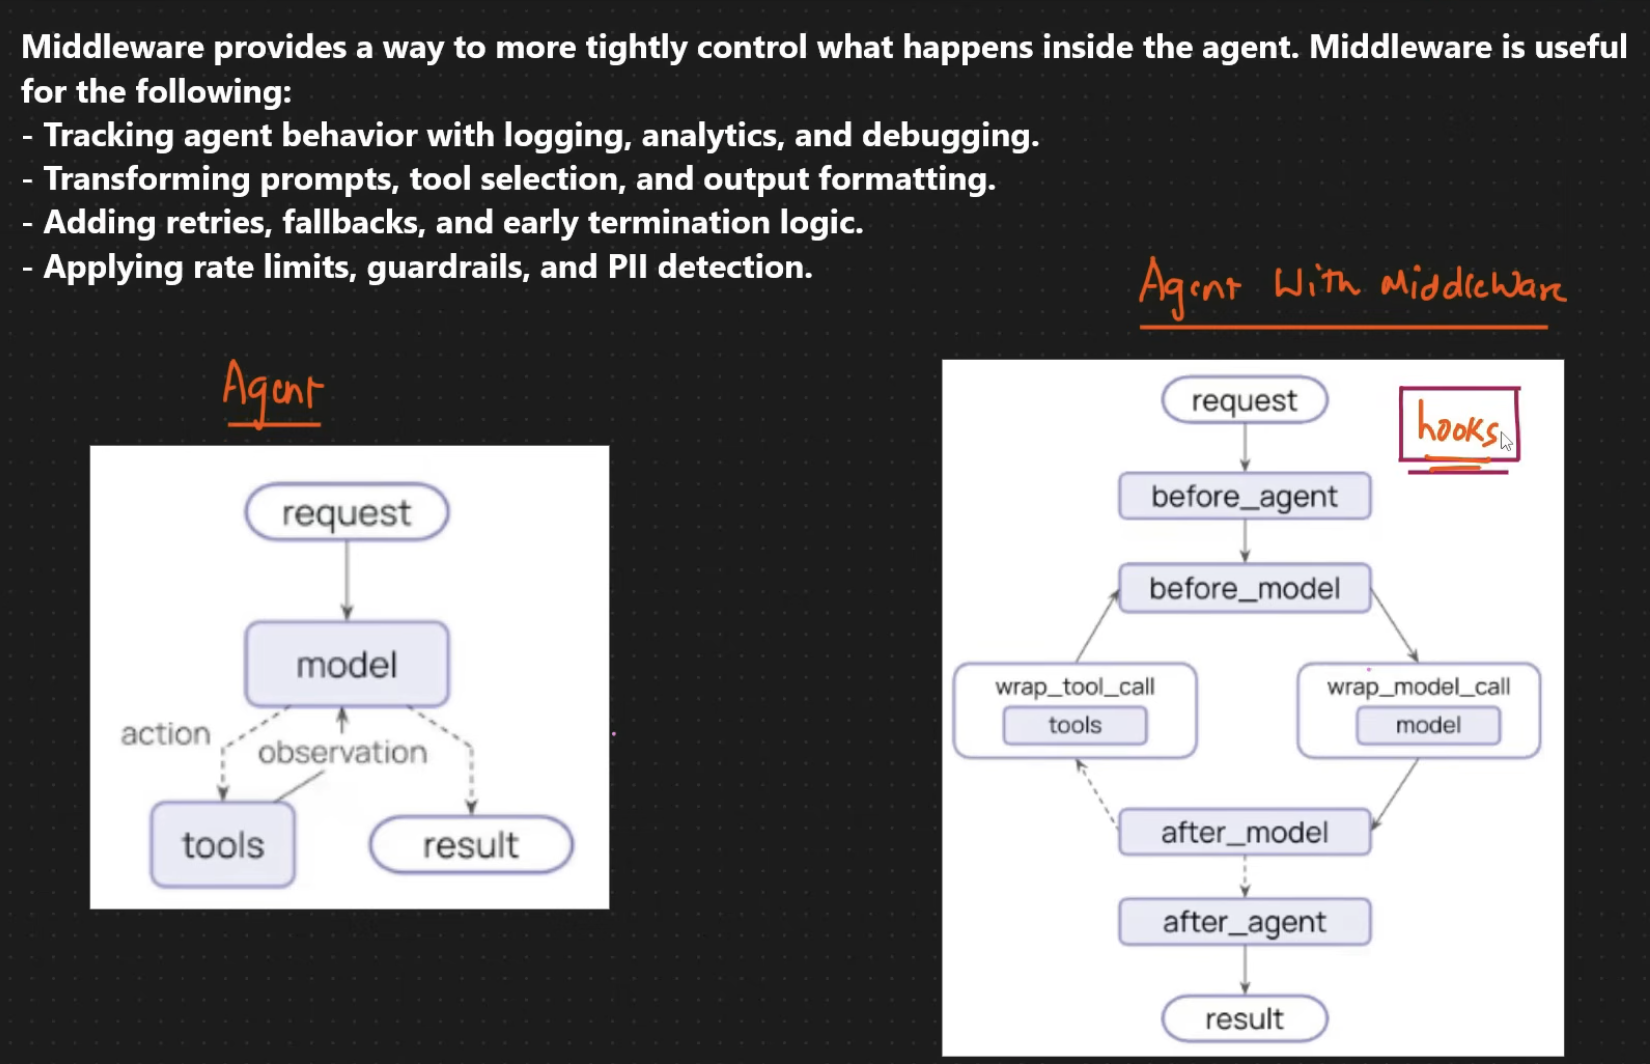

In [1]:
import os
from langchain.chat_models import init_chat_model

# os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

/app/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Summarization Middleware

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:
- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

In [2]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage



## Message based summmarization ->Add middleware inside the agent
agent = create_agent(
    model="groq:qwen/qwen3-32b",
    checkpointer=InMemorySaver(), # * Save it in the local hardisk itself
    middleware=[
        SummarizationMiddleware( # * Always use less cost in terms of token
            model="groq:llama-3.1-8b-instant",
            trigger=("messages", 10), # * Condition (when I want the Summarization middleware should get kicked in)
            keep=("messages", 4) # * When u do summariziation keep the recent top 4 context
        )
    ]
)

In [3]:
### Run with thread id
config = {"configurable": {"thread_id": "test-12"}}

In [4]:
# Alternative test data
questions = [
    "What is 2+2 ?",
    "What is 63/5 ?",
    "What is 100/4 ?",
    "What is 9445%3 ?",
    "What is 2+15-7 ?",
    "What is 698*9 ?",
    "What is 2+5 ?",
]

for i, q in enumerate(questions):
    config = {"configurable": {"thread_id": f"q-{i}"}}
    response = agent.invoke({"messages": [HumanMessage(content=q)]}, config)
    print(f"Q: {q}")
    print(f"A: {response['messages'][-1].content[:50]}\n")

Q: What is 2+2 ?
A: <think>
Okay, so I need to figure out what 2 plus 

Q: What is 63/5 ?
A: <think>
Okay, so I need to figure out what 63 divi

Q: What is 100/4 ?
A: <think>
Okay, let me try to figure out what 100 di

Q: What is 9445%3 ?
A: <think>
Okay, so I need to figure out what 9445 di

Q: What is 2+15-7 ?
A: <think>
Okay, let's see. I need to solve the math 

Q: What is 698*9 ?
A: <think>
Okay, let's see. I need to calculate 698 m

Q: What is 2+5 ?
A: <think>
Okay, let's see. The question is asking wh



### Token Size

In [5]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool


@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi
    """


agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[SummarizationMiddleware(
        model="groq:llama-3.1-8b-instant",
        trigger=("tokens", 550), # When trigger exceeds 550 then call the summarizationMiddleware
        keep=("tokens", 200)
    )], 
)


config = {"configurable": {"thread_id": "test-1"}}

# token counter (approximate)
def count_token(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4 # * 4 chars = 1 token

In [6]:
# Run Test
cities = ["Paris", "London", "Tokyo", "Tamil Nadu", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find Hotels in {city}")]},
        config=config
    )

    token = count_token(response["messages"])
    print(f"{city}: ~{token} tokens, {len(response['messages'])} messages")
    print(f"{response['messages']}")

Paris: ~156 tokens, 4 messages
[HumanMessage(content='Find Hotels in Paris', additional_kwargs={}, response_metadata={}, id='7e2075ae-d503-4dab-8289-d6addb121022'), AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user wants to find hotels in Paris. Let me check the available tools. There\'s a function called search_hotels that takes a city parameter. The description says it returns a long response to use more tokens. Hmm, maybe the response is detailed, which is good for the user. I need to call this function with the city set to Paris. Let me make sure the parameters are correct. The required field is city, and it\'s a string. So I should structure the tool call with "name" as "search_hotels" and the arguments as {"city": "Paris"}. That\'s all the info needed. Let me output the tool call in the specified JSON format within the XML tags.\n', 'tool_calls': [{'id': 'n0wtmdypr', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'funct

### Fraction

In [9]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool


@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi
    """


agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[SummarizationMiddleware(
        model="groq:qwen/qwen3-32b",
        trigger=("fraction", 0.005), # When trigger exceeds 550 then call the summarizationMiddleware-> 0.5% = ~640; 02% = ~256 token   
        keep=("fraction", 0.002)
    )], 
)


config = {"configurable": {"thread_id": "test-1"}}

# token counter (approximate)
def count_token(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4 # * 4 chars = 1 token

## Human In the loop Middleware

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:
- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.
- Autonomous Agent: Without Human intervention agent will do its task

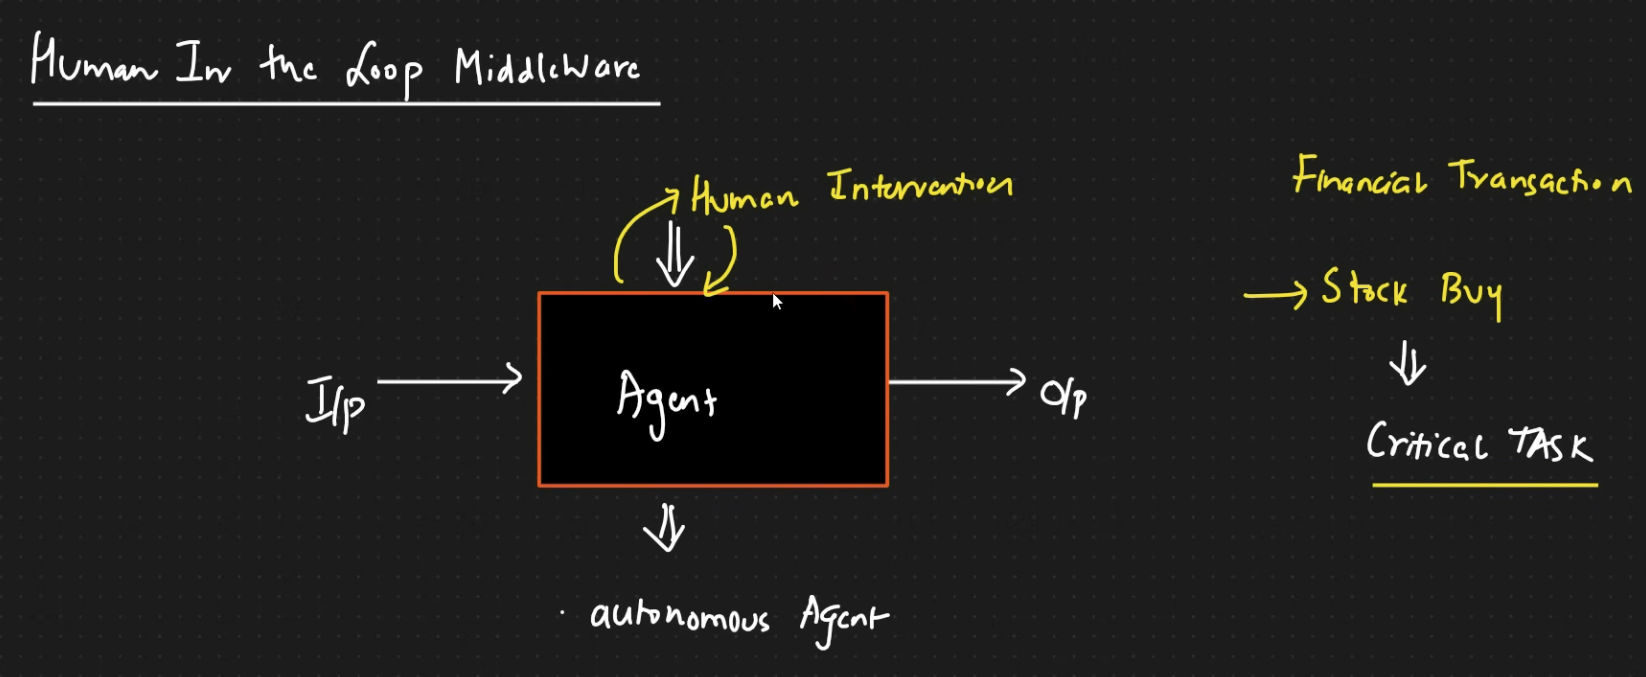

In [10]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool



# Agent should ask continuous feedback
def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID"""
    return f"Email content for ID: {email_id}"


def send_email_tool(receipient: str, subject: str, body: str) -> str:
    """Mock function to send an email"""
    return f"Email sent {receipient} wih subject '{subject}'"

In [11]:
agent = create_agent(
    model="gpt-5.4-mini",
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"]  # "approve", not "approved"
                },
                "read_email_tool": False
            }
        )
    ]
)

In [12]:
config = {"configurable": {"thread_id": "test-approve1"}}

# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to jogn@gmail.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [13]:
result

{'messages': [HumanMessage(content="Send email to jogn@gmail.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='6164302e-4c38-40b4-981d-6ac3aee9dbe5'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 180, 'total_tokens': 213, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-E1syA0wAqnLrWrsh2UuzcQbsXNRLS', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f65bd-5d65-7c02-b826-bb1be93eb385-0', tool_calls=[{'name': 'send_email_tool', 'args': {'receipient': 'jogn@gmail.com', 'subject': 'Hello', 'body': 'How are you?'}, '

### Approve

In [14]:
# Step 2
from langgraph.types import Command


if "__interrupt__" in result:
    print("Paused! Approving")

    result = agent.invoke(
        Command(
            resume={
                "decisions": [{"type": "approve"}]
            }
        ),
        config=config
    )

    print(f" Result: {result['messages'][-1].content}")


Paused! Approving
 Result: Done.


### Reject

In [15]:
config = {"configurable": {"thread_id": "test-reject"}}

# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to jogn@gmail.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [16]:
from langgraph.types import Command


if "__interrupt__" in result:
    print("Paused! Rejecting")

    result = agent.invoke(
        Command(
            resume={
                "decisions": [{"type": "reject"}]
            }
        ),
        config=config
    )

    print(f" Result: {result['messages'][-1].content}")


Paused! Rejecting
 Result: I can’t send it because the tool call was rejected. If you want, I can try again with the same details or help you draft the email.


### Edit

In [17]:
config = {"configurable": {"thread_id": "test-edit1"}}

# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to jogn@gmail.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [18]:
result

{'messages': [HumanMessage(content="Send email to jogn@gmail.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='fb8becb3-ab30-4d3a-bfba-6d2cae956edc'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 180, 'total_tokens': 213, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-E1syZy4VZTptwxhRcM1mAPjBFb75z', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f65bd-c24c-7440-8312-6154929f3471-0', tool_calls=[{'name': 'send_email_tool', 'args': {'receipient': 'jogn@gmail.com', 'subject': 'Hello', 'body': 'How are you?'}, '

In [19]:
from langgraph.types import Command


if "__interrupt__" in result:
    print("Paused! Editing")

    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool", # * Tool name
                            "args": { # * New Arguments
                                "recipient": "correct@gmail.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )

    print(f" Result: {result}")


Paused! Editing
 Result: {'messages': [HumanMessage(content="Send email to jogn@gmail.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='fb8becb3-ab30-4d3a-bfba-6d2cae956edc'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 180, 'total_tokens': 213, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-E1syZy4VZTptwxhRcM1mAPjBFb75z', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f65bd-c24c-7440-8312-6154929f3471-0', tool_calls=[{'type': 'tool_call', 'name': 'send_email_tool', 'args': {'recipient': 'correct@gmail.com', 